In [1]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import nitools as nt
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
from imaging_pipelines.vis import plot_surf
import PcmPy as pcm
from EFC_learningfMRI.G_matrix import G_sorted
from EFC_learningfMRI.util import get_trained_and_untrained, ttest_im_sess
from EFC_learningfMRI.pcm import make_models
from matplotlib.colors import LinearSegmentedColormap, Normalize
import statsmodels.formula.api as smf
import itertools
import nibabel as nb
import warnings

warnings.filterwarnings('ignore')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants

# Representational geometry at session 3
*Compare with model components below

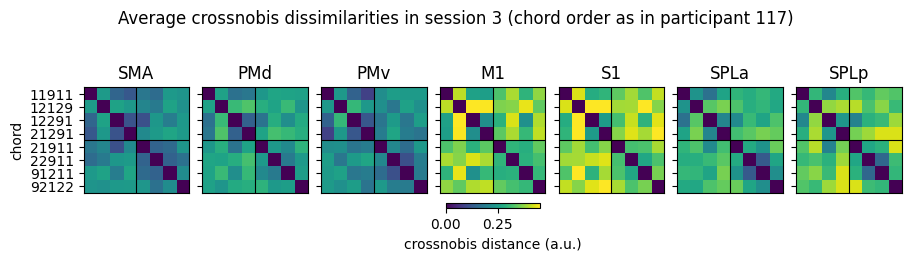

In [3]:
# Plot example Distance matrix of one subject for one session 
# from the G_obs_raw across ROIs 

sn = 116
session = 23

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(9, 2.5))

vmin, vmax = 0, .45

for r, roi in enumerate(rois):
    G  = []
    for sn in sns:
        G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs_raw.within_session.{session}.glm{glm}.{H}.{roi}.npy')))
    G  = np.array(G)

    ax = axs[r]
    G_sort  = G_sorted(G, sns, order=get_trained_and_untrained(sn))
    D  = pcm.G_to_dist(G_sort)
    D  = np.sign(D) * np.sqrt(np.abs(D))
    im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([])
    ax.set_yticks(np.arange(8))
    #ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

axs[0].set_ylabel('chord')

fig.colorbar(im, ax=axs, fraction=.03, label='crossnobis distance (a.u.)', orientation='horizontal')

fig.suptitle(f'Average crossnobis dissimilarities in session 3 (chord order as in participant {sn})')

fig.savefig(f'figures/crossnobis_example_{sn}.pdf')

plt.show()

# Crossnobis dissimilarities between activity patterns for trained and untrained chords
In M1 and S1, activity patterns for trained chords are more distant among each other compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0  -0.494138   14  0.628871  [-0.02, 0.01]   SMA        3
3  -0.346264   14  0.734293  [-0.02, 0.01]   PMd        3
6  -0.415123   14  0.684343  [-0.03, 0.02]   PMv        3
9  -0.154189   14  0.879661  [-0.05, 0.04]    M1        3
12 -0.689950   14  0.501503  [-0.05, 0.02]    S1        3
15 -1.191193   14  0.253382  [-0.05, 0.01]  SPLa        3
18 -0.989032   14  0.339434  [-0.05, 0.02]  SPLp        3
7  -0.223581   14  0.826313  [-0.04, 0.03]   PMv        9
13  0.790459   14  0.442445  [-0.03, 0.06]    S1        9
10  0.761493   14  0.458999  [-0.03, 0.06]    M1        9
4  -1.029222   14  0.320830  [-0.04, 0.01]   PMd        9
1   0.056929   14  0.955406  [-0.02, 0.02]   SMA        9
16 -0.123998   14  0.903080  [-0.03, 0.03]  SPLa        9
19 -0.019000   14  0.985109  [-0.03, 0.03]  SPLp        9
5  -0.281087   14  0.782755  [-0.02, 0.01]   PMd       23
2  -0.607076   14  0.553519  [-0.01, 0.01]   SMA       23
14  0.531140  

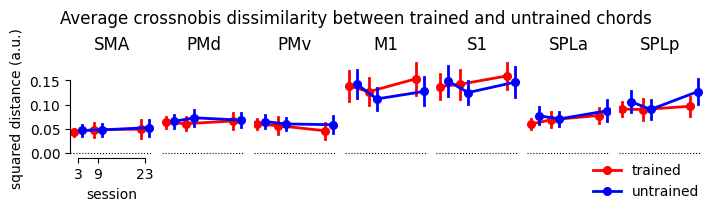

In [4]:
hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist = dist[(dist.Hem=='L') & (dist.chord.isin(hue_order))]
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Average crossnobis dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/crossnobis_mean.pdf')

plt.show()

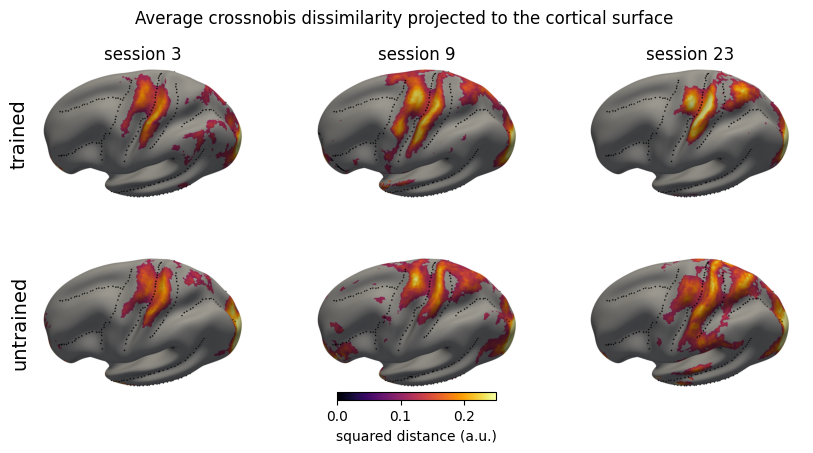

In [5]:
thresh = .1
vmin, vmax = 0, .25
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('encoding-trained')
    untr_col = cols.index('encoding-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='squared distance (a.u.)')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Average crossnobis dissimilarity projected to the cortical surface')

fig.savefig('figures/crossnobis_searchlight.pdf')

plt.show()

# Angle between activity patterns for trained and untrained chords
The angles between activity patterns for trained chords are also wider compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0   0.686531   14  0.503591  [-0.01, 0.01]   SMA        3
3   0.197389   14  0.846360  [-0.01, 0.01]   PMd        3
6   0.537655   14  0.599258  [-0.01, 0.02]   PMv        3
9   0.821695   14  0.425024  [-0.01, 0.02]    M1        3
12  0.749044   14  0.466231  [-0.01, 0.02]    S1        3
15  0.517496   14  0.612889  [-0.01, 0.02]  SPLa        3
18  1.060324   14  0.306948  [-0.01, 0.02]  SPLp        3
7  -0.537674   14  0.599246  [-0.02, 0.01]   PMv        9
13 -1.099035   14  0.290294  [-0.02, 0.01]    S1        9
10  0.192647   14  0.850002  [-0.01, 0.01]    M1        9
4  -0.192534   14  0.850089  [-0.01, 0.01]   PMd        9
1   0.861244   14  0.403614  [-0.01, 0.01]   SMA        9
16 -0.860451   14  0.404036  [-0.02, 0.01]  SPLa        9
19  0.077829   14  0.939066  [-0.01, 0.01]  SPLp        9
5  -0.636877   14  0.534481  [-0.01, 0.01]   PMd       23
2  -0.220517   14  0.828652  [-0.02, 0.01]   SMA       23
14 -2.078756  

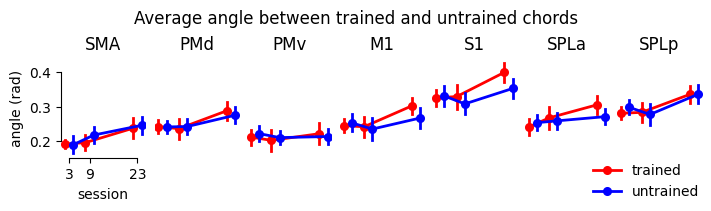

In [6]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Average angle between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='cosine', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/angle_mean.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.430434   14  0.673433  [-0.02, 0.01]   SMA        3
3  -0.687691   14  0.502882  [-0.02, 0.01]   PMd        3
6  -0.496648   14  0.627145  [-0.04, 0.02]   PMv        3
9  -1.417821   14  0.178116  [-0.07, 0.01]    M1        3
12 -1.259527   14  0.228434  [-0.07, 0.02]    S1        3
15 -1.362918   14  0.194429  [-0.05, 0.01]  SPLa        3
18 -0.822575   14  0.424539  [-0.04, 0.02]  SPLp        3
7  -0.421539   14  0.679762  [-0.04, 0.03]   PMv        9
13  1.191431   14  0.253292  [-0.01, 0.05]    S1        9
10  0.420321   14  0.680631  [-0.02, 0.04]    M1        9
4  -1.226485   14  0.240245  [-0.03, 0.01]   PMd        9
1   0.275445   14  0.786998  [-0.02, 0.02]   SMA        9
16 -0.009928   14  0.992219  [-0.03, 0.03]  SPLa        9
19  0.171641   14  0.866176  [-0.02, 0.03]  SPLp        9
5   0.470489   14  0.645251  [-0.03, 0.04]   PMd       23
2   0.291090   14  0.775251  [-0.04, 0.05]   SMA       23
14  1.654429  

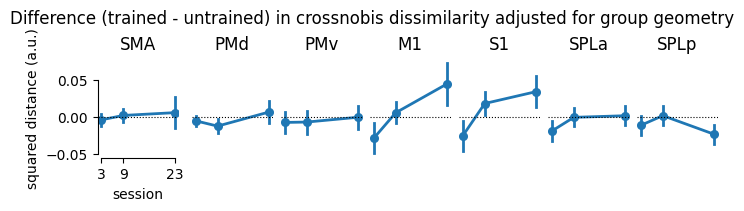

In [16]:
dist_ancova = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
dist_ancova_crossnobis = dist_ancova[(dist_ancova.Hem==H) & (dist_ancova.metric=='crossnobis')]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_ancova_crossnobis, rois, y='adjusted', x='session', kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Difference (trained - untrained) in crossnobis dissimilarity adjusted for group geometry')

ttest = ttest_im_sess(dist_ancova_crossnobis, rois, y='adjusted', x='session',)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])



plt.show()

           T  dof     p_val           CI95   roi  session
0   0.114141   14  0.910747  [-0.05, 0.05]   SMA        3
3   0.057502   14  0.954958  [-0.03, 0.04]   PMd        3
6  -0.153532   14  0.880169  [-0.05, 0.05]   PMv        3
9  -0.574174   14  0.574960  [-0.05, 0.03]    M1        3
12  0.016534   14  0.987042  [-0.04, 0.04]    S1        3
15 -0.611761   14  0.550502  [-0.06, 0.03]  SPLa        3
18 -0.428697   14  0.674666  [-0.05, 0.03]  SPLp        3
7   0.034368   14  0.973069  [-0.06, 0.06]   PMv        9
13  1.288604   14  0.218424  [-0.02, 0.08]    S1        9
10  0.673996   14  0.511289  [-0.03, 0.06]    M1        9
4   0.171196   14  0.866520  [-0.04, 0.05]   PMd        9
1  -0.054817   14  0.957059  [-0.05, 0.04]   SMA        9
16  0.728787   14  0.478147  [-0.03, 0.06]  SPLa        9
19  1.078767   14  0.298928  [-0.02, 0.06]  SPLp        9
5   1.791982   14  0.094768  [-0.01, 0.09]   PMd       23
2   0.021318   14  0.983293  [-0.08, 0.08]   SMA       23
14  2.692715  

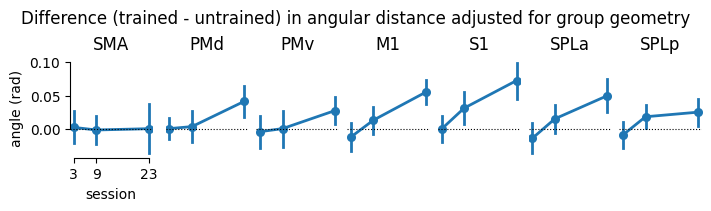

In [15]:
dist_ancova = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
dist_ancova_theta = dist_ancova[(dist_ancova.Hem==H) & (dist_ancova.metric=='theta')]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_ancova_theta, rois, y='adjusted', x='session', kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Difference (trained - untrained) in angular distance adjusted for group geometry')

ttest = ttest_im_sess(dist_ancova_theta, rois, y='adjusted', x='session',)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])



plt.show()

# Activity vs. dissimilarity
- Activity $a$ for trained and untrained chords was estimated from the cross-validated G-matrix as: $a = \frac{1}{K}\sum_{k=1}^{K}\sqrt{G_{kk}}$; where $K=4$ is the number of chords within the trained and untrained set.

- Dissimilarity $d$ between trained and untrained chords was estimated as the mean off-diagonal crossnobis distance $d = \frac{2}{K(K-1)}\sum_{k<l}\sqrt{D_{kl}}$ over the same conditions, with $D = $ `pcm.G_to_dist(G)`.

- The predicted dissimilarity in session 9 (and 23) if patterns only scaled with activity would be $\hat d_9 = \frac{a_9}{a_3} d_3$; $d_9 - \hat d_9$ (the `residual`) larger than 0 would occur if the patterns separated by more than a change in activity alone can account for.

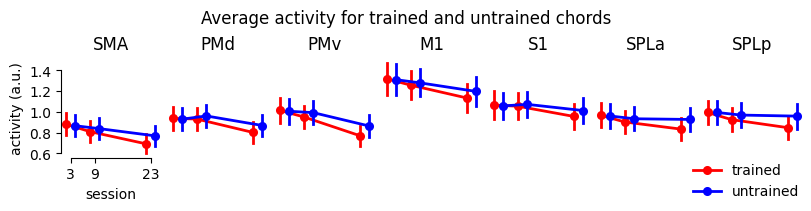

In [10]:
scaling = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'scaling.between_session.glm{glm}.{atlas}.tsv'), sep='\t')
scaling = scaling[scaling.Hem==H]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='act_target', hue='chord', hue_order=hue_order, palette=palette, estimator='mean', add_zero=False, dodge=.4)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('activity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

fig.suptitle('Average activity for trained and untrained chords')

plt.show()

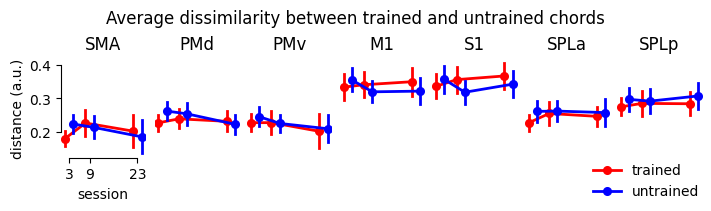

In [11]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois, y='diss_target_observed', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('distance (a.u.)')

fig.suptitle('Average dissimilarity between trained and untrained chords')

plt.show()

           T  dof     p_val           CI95   roi  session
0        NaN    6       NaN     [nan, nan]   SMA        3
3        NaN   10       NaN     [nan, nan]   PMd        3
6        NaN    9       NaN     [nan, nan]   PMv        3
9        NaN   13       NaN     [nan, nan]    M1        3
12       NaN   13       NaN     [nan, nan]    S1        3
15       NaN   11       NaN     [nan, nan]  SPLa        3
18       NaN   13       NaN     [nan, nan]  SPLp        3
7   0.967406    8  0.361673  [-0.05, 0.12]   PMv        9
13  4.036857   12  0.001649   [0.02, 0.08]    S1        9
10  1.887643   10  0.088404   [-0.01, 0.1]    M1        9
4   0.613481    8  0.556595  [-0.03, 0.06]   PMd        9
1   2.707209    4  0.053692   [-0.0, 0.17]   SMA        9
16  2.061756    9  0.069283   [-0.0, 0.09]  SPLa        9
19  1.849624   11  0.091396  [-0.01, 0.08]  SPLp        9
5   2.192774    8  0.059662   [-0.0, 0.06]   PMd       23
2   5.270795    1  0.119364  [-0.06, 0.15]   SMA       23
14  3.516630  

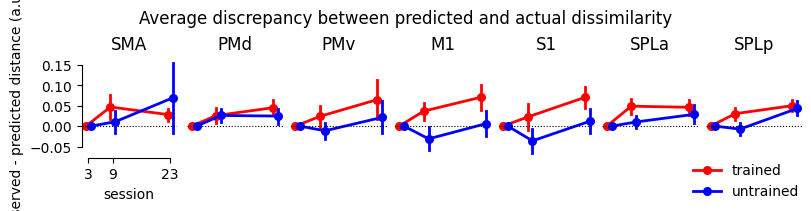

In [12]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='residual', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], estimator='mean', add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('observed - predicted distance (a.u.)')

fig.suptitle('Average discrepancy between predicted and actual dissimilarity')

ttest = ttest_im_sess(scaling, rois, y='residual', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()